# **In-class Competition: Predictive Modelling**
Predict 30 day cumulative views using only early engagement metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


train_videos=pd.read_csv('train_videos.csv')
creators_daily=pd.read_csv('creators_daily.csv')
engagment=pd.read_csv('engagement_daily.csv')
test_videos=pd.read_csv('test_videos.csv')

train_videos.head()

,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,...,hashtag_count,speaking_rate,topic,anger,joy,surprise,sadness,disgust,fear,target_day30_views
0,7389777708642798891,6823500943611528198,2024-07-09 18:11:50,2024-07-09,61.230,540p,en,1,0.0,0,...,4.0,6.532745,Lifestyle,0.003960,0.790962,0.017963,0.002873,0.004761,0.001092,1371
1,7414315783221693739,6851716737763886085,2024-09-13 21:12:02,2024-09-13,58.095,540p,en,1,0.0,0,...,6.0,4.148378,Beauty_Fashion,0.004058,0.767556,0.003882,0.012160,0.019463,0.001298,1184
2,7408397785503943942,6809119722295968773,2024-08-28 22:27:16,2024-08-28,7.431,720p,en,1,0.0,0,...,4.0,0.000000,Life_hacks_Personal_growth,0.003275,0.849156,0.003241,0.007868,0.005667,0.003849,638
3,7406460852611681567,6790225026127627269,2024-08-23 17:11:01,2024-08-23,15.046,540p,un,0,0.0,0,...,0.0,0.000000,Beauty_Fashion,0.004971,0.612373,0.006764,0.010911,0.066338,0.001878,312
4,7428770082219756831,2033984,2024-10-22 20:02:15,2024-10-22,7.895,540p,en,1,0.0,0,...,NaN,NaN,Beauty_Fashion,0.022163,0.006064,0.008672,0.041306,0.474281,0.022709,180


In [2]:
creators_daily.head()

,author_id,date,follower_count,following_count,total_favorited,video_count,enterprise_verified
0,10245051,2024-06-27,1704.0,1039.0,75987,83.0,NaN
1,10245051,2024-06-28,1704.0,1039.0,76018,83.0,NaN
2,10245051,2024-06-29,1704.0,1039.0,76024,83.0,NaN
3,10245051,2024-06-30,1704.0,1039.0,76025,83.0,NaN
4,10245051,2024-07-01,1704.0,1039.0,76029,83.0,NaN


In [3]:
engagment.head()

,video_id,date,days_since_post,play_count,like_count,comment_count,share_count,collect_count,download_count,whatsapp_share_count
0,7384086821132717358,2024-06-24,0,105696,6249,23,1113,1737,59,5
1,7384086821132717358,2024-06-25,1,330084,25291,71,3689,6421,214,25
2,7384086821132717358,2024-06-26,2,390753,32925,93,4476,8082,272,30
3,7384086821132717358,2024-06-27,3,464862,45741,137,5756,10699,358,33
4,7384086821132717358,2024-06-28,4,475386,46896,143,5907,10926,366,33


In [4]:
test_videos.head()

,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,...,question_count,hashtag_count,speaking_rate,topic,anger,joy,surprise,sadness,disgust,fear
0,7400582591771938090,6986770031481095173,2024-08-07 21:00:13,2024-08-07,10.100,540p,un,0,0.0,0,...,0.0,2.0,3.564356,Life_hacks_Personal_growth,0.002676,0.938924,0.005082,0.002898,0.009154,0.000414
1,7403167206978374958,6761640179813254150,2024-08-14 20:09:53,2024-08-14,13.815,540p,un,0,1.0,0,...,0.0,5.0,0.000000,Dance_Music,0.003034,0.840657,0.005514,0.035231,0.010021,0.000603
2,7435124823820356906,6926128790248080390,2024-11-08 22:01:44,2024-11-08,10.600,540p,un,0,0.0,0,...,NaN,NaN,NaN,Life_hacks_Personal_growth,0.013941,0.821651,0.003380,0.018616,0.032773,0.000685
3,7409800970143714606,6930420307368199173,2024-09-01 17:12:16,2024-09-01,38.289,540p,en,1,0.0,0,...,0.0,39.0,3.708637,Lifestyle,0.002326,0.958039,0.002441,0.003065,0.005616,0.000298
4,7410935177553333550,6880023927025468421,2024-09-04 18:33:33,2024-09-04,14.883,540p,en,1,0.0,0,...,0.0,6.0,5.240879,Beauty_Fashion,0.003002,0.906478,0.004138,0.002237,0.003371,0.001028


In [5]:
print('train shape:', train_videos.shape)
print(train_videos.columns)

print("__________________________")

print('creators shape:', creators_daily.shape)
print(creators_daily.columns)

print("__________________________")

print('engagment shape:', engagment.shape)
print(engagment.columns)

print("__________________________")

print('test shape:', test_videos.shape)
print(test_videos.columns)

train shape: (12000, 27)
Index(['video_id', 'author_id', 'create_time', 'create_date', 'duration',
       'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads',
       'music_selected_from', 'music_author', 'music_owner_id', 'music_id',
       'word_count', 'emoji_count', 'question_count', 'hashtag_count',
       'speaking_rate', 'topic', 'anger', 'joy', 'surprise', 'sadness',
       'disgust', 'fear', 'target_day30_views'],
      dtype='str')
__________________________
creators shape: (252166, 7)
Index(['author_id', 'date', 'follower_count', 'following_count',
       'total_favorited', 'video_count', 'enterprise_verified'],
      dtype='str')
__________________________
engagment shape: (79489, 10)
Index(['video_id', 'date', 'days_since_post', 'play_count', 'like_count',
       'comment_count', 'share_count', 'collect_count', 'download_count',
       'whatsapp_share_count'],
      dtype='str')
__________________________
test shape: (3001, 26)
Index(['video_id', 'author_id',

In [6]:
cols=[
    'play_count',
    'like_count',
    'comment_count',
    'share_count',
    'collect_count',
    'download_count',
    'whatsapp_share_count'
]

engagment_agg=engagment.groupby('video_id')[cols].sum().reset_index()

In [7]:
creators_daily['date']=pd.to_datetime(creators_daily['date'])

In [8]:
train_videos['target_day30_views'] = (train_videos['target_day30_views'].round().astype(int))

In [9]:
print(train_videos['create_date'].dtype)
train_videos['create_date']=pd.to_datetime(train_videos['create_date'])
train_videos['create_time']=pd.to_datetime(train_videos['create_time']).dt.hour

str


# Merge
3 tabels which is train_videos , engagement , creators_daily

In [10]:
creator_features = train_videos.merge(
    creators_daily,
    left_on=['author_id', 'create_date'],
    right_on=['author_id', 'date'],
    how='left'
)

print(creator_features.shape)
creator_features.columns

(12000, 33)


Index(['video_id', 'author_id', 'create_time', 'create_date', 'duration',
       'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads',
       'music_selected_from', 'music_author', 'music_owner_id', 'music_id',
       'word_count', 'emoji_count', 'question_count', 'hashtag_count',
       'speaking_rate', 'topic', 'anger', 'joy', 'surprise', 'sadness',
       'disgust', 'fear', 'target_day30_views', 'date', 'follower_count',
       'following_count', 'total_favorited', 'video_count',
       'enterprise_verified'],
      dtype='str')

In [11]:
final_train = creator_features.merge(
    engagment_agg,
    on='video_id',
    how='left'
)
print(final_train.shape)
final_train.columns

(12000, 40)


Index(['video_id', 'author_id', 'create_time', 'create_date', 'duration',
       'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads',
       'music_selected_from', 'music_author', 'music_owner_id', 'music_id',
       'word_count', 'emoji_count', 'question_count', 'hashtag_count',
       'speaking_rate', 'topic', 'anger', 'joy', 'surprise', 'sadness',
       'disgust', 'fear', 'target_day30_views', 'date', 'follower_count',
       'following_count', 'total_favorited', 'video_count',
       'enterprise_verified', 'play_count', 'like_count', 'comment_count',
       'share_count', 'collect_count', 'download_count',
       'whatsapp_share_count'],
      dtype='str')

# Feature engineering

In [12]:
final_train['share_rate'] = final_train['share_count'] / final_train['play_count']
final_train['like_rate'] = final_train['like_count'] / final_train['play_count']
final_train['comment_rate'] = final_train['comment_count'] / final_train['play_count']
final_train['collect_rate'] = final_train['collect_count'] / final_train['play_count']
final_train['download_rate'] = final_train['download_count'] / final_train['play_count']
final_train['whatsapp_share_rate'] = final_train['whatsapp_share_count'] / final_train['play_count']


ratio_cols = [
    'share_rate',
    'like_rate',
    'comment_rate',
    'collect_rate',
    'download_rate',
    'whatsapp_share_rate'
]

for col in ratio_cols:
    final_train[col] = final_train[col].fillna(final_train[col].median())

In [13]:
final_train[['share_rate',
             'like_rate',
             'comment_rate',
             'collect_rate',
             'download_rate',
             'whatsapp_share_rate']].isna().sum()

share_rate             0
like_rate              0
comment_rate           0
collect_rate           0
download_rate          0
whatsapp_share_rate    0
dtype: int64

In [14]:
final_train = final_train.replace([np.inf, -np.inf], np.nan)

final_train[['share_rate',
             'like_rate',
             'comment_rate',
             'collect_rate',
             'download_rate',
             'whatsapp_share_rate']].isin([np.inf,-np.inf]).sum()

share_rate             0
like_rate              0
comment_rate           0
collect_rate           0
download_rate          0
whatsapp_share_rate    0
dtype: int64

# handle with missing values in final_train

In [15]:
final_train.isna().sum().sort_values(ascending=False)

#drop it because it.s embty
final_train = final_train.drop(columns=['enterprise_verified'])

#full all of this by median
text_cols = [
    'hashtag_count',
    'emoji_count',
    'question_count',
    'word_count',
    'speaking_rate'
]

for col in text_cols:
    final_train[col] = final_train[col].fillna(final_train[col].median())


final_train['music_owner_id'] = final_train['music_owner_id'].fillna(-1)
final_train['music_selected_from'] = final_train['music_selected_from'].fillna('Unknown')
final_train['music_author'] = final_train['music_author'].fillna('Unknown')
final_train['music_id'] = final_train['music_id'].fillna(-1)



In [16]:
emotion_cols = [
    'anger', 'joy', 'surprise',
    'sadness', 'disgust', 'fear'
]

for col in emotion_cols:
    final_train[col] = final_train[col].fillna(final_train[col].median())

In [17]:
engagement_cols = [
    'play_count',
    'like_count',
    'comment_count',
    'share_count',
    'collect_count',
    'download_count',
    'whatsapp_share_count'
]


final_train = final_train.dropna(
    subset=engagement_cols,
    how='all'
).reset_index(drop=True)



In [18]:
final_train=final_train.drop(columns=['date','create_date'])


In [19]:
final_train['like_rate']=final_train['like_rate'].fillna(final_train['like_rate'].median())
final_train['topic']=final_train['topic'].fillna('Unknown')
final_train = final_train.dropna(subset=['target_day30_views']).reset_index(drop=True)

In [20]:
missing_creator = final_train[
    final_train['follower_count'].isna()
]

missing_creator['author_id'].isin(
    creators_daily['author_id']
).mean()

nan

In [21]:
final_train.isna().sum()[final_train.isna().sum()>0]

Series([], dtype: int64)

In [22]:
final_train.isna().sum().sort_values(ascending=False)

video_id                0
author_id               0
create_time             0
duration                0
ratio                   0
desc_language           0
is_english              0
created_by_ai           0
is_ads                  0
music_selected_from     0
music_author            0
music_owner_id          0
music_id                0
word_count              0
emoji_count             0
question_count          0
hashtag_count           0
speaking_rate           0
topic                   0
anger                   0
joy                     0
surprise                0
sadness                 0
disgust                 0
fear                    0
target_day30_views      0
follower_count          0
following_count         0
total_favorited         0
video_count             0
play_count              0
like_count              0
comment_count           0
share_count             0
collect_count           0
download_count          0
whatsapp_share_count    0
share_rate              0
like_rate   

# **EDA**

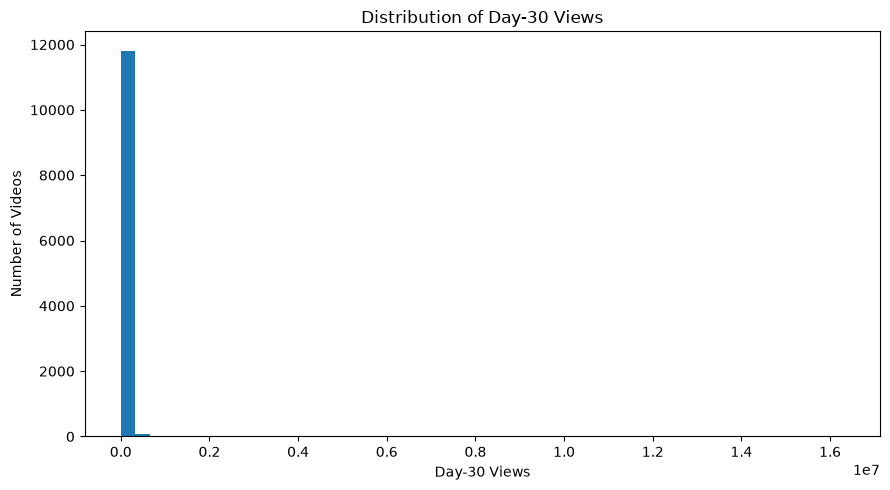

In [23]:
plt.figure(figsize=(9, 5))

plt.hist(final_train['target_day30_views'], bins=50)

plt.xlabel('Day-30 Views')
plt.ylabel('Number of Videos')
plt.title('Distribution of Day-30 Views')

plt.tight_layout()
plt.show()

the target is highly right-skewed

Log scale helps us visualize the highly skewed target distribution more clearly.

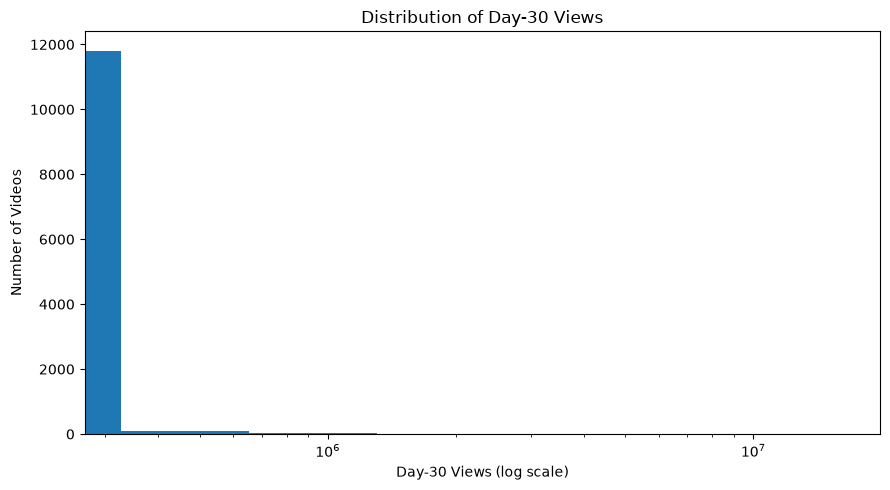

In [24]:
plt.figure(figsize=(9, 5))

plt.hist(final_train['target_day30_views'], bins=50)

plt.xscale('log')

plt.xlabel('Day-30 Views (log scale)')
plt.ylabel('Number of Videos')
plt.title('Distribution of Day-30 Views')

plt.tight_layout()
plt.show()

## Correlation helps us identify numeric features that are related to the target.

In [25]:
corr = final_train.select_dtypes(include='number').corr()['target_day30_views']

corr.sort_values(ascending=False)

target_day30_views      1.000000
play_count              0.938439
like_count              0.857842
collect_count           0.628989
share_count             0.610043
whatsapp_share_count    0.558480
comment_count           0.486418
download_count          0.389860
follower_count          0.262650
total_favorited         0.254355
is_english              0.060402
share_rate              0.058599
question_count          0.054694
word_count              0.049488
surprise                0.049430
collect_rate            0.036401
duration                0.032145
like_rate               0.026131
speaking_rate           0.023951
whatsapp_share_rate     0.020475
disgust                 0.016804
video_id                0.014454
download_rate           0.008470
video_count             0.006480
music_id                0.006308
sadness                 0.003898
hashtag_count          -0.002221
joy                    -0.002236
anger                  -0.002559
fear                   -0.006033
created_by

## examine whether early engagement is related to Day-30 views.

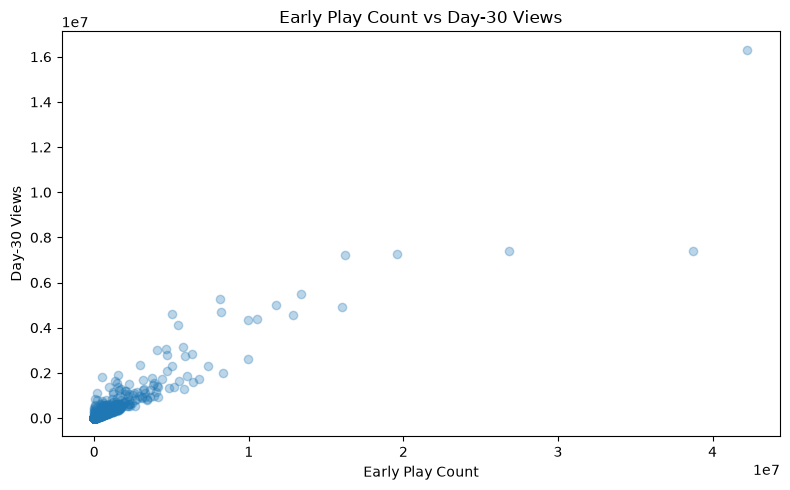

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    final_train['play_count'],
    final_train['target_day30_views'],
    alpha=0.3
)

plt.xlabel('Early Play Count')
plt.ylabel('Day-30 Views')
plt.title('Early Play Count vs Day-30 Views')

plt.tight_layout()
plt.show()

## Early likes may provide useful information for predicting long-term video views.

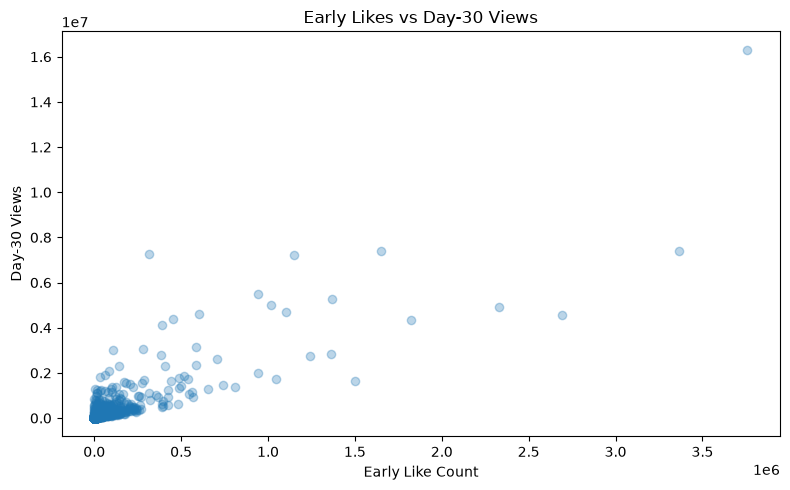

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    final_train['like_count'],
    final_train['target_day30_views'],
    alpha=0.3
)

plt.xlabel('Early Like Count')
plt.ylabel('Day-30 Views')
plt.title('Early Likes vs Day-30 Views')

plt.tight_layout()
plt.show()

# **Split data**

In [28]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.impute import SimpleImputer


X=final_train.drop(columns=['target_day30_views'])
y=final_train['target_day30_views']
X_train ,X_val , y_train , y_val = train_test_split(X , y ,test_size=0.2 , random_state=42 )


categorical_cols=[
    'ratio',
    'desc_language',
    'music_selected_from',
    'music_author',
    'topic'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


model_lr=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

model_lr.fit(X_train,y_train)
y_pred=model_lr.predict(X_val)


rmse=root_mean_squared_error(y_val,y_pred)
print(f'RSME Linear regression: {rmse:.3f}')



RSME Linear regression: 266523.871


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_params = [ {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1.0}, {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1.0}, {'n_estimators': 700, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1.0},
{'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 1.0},
{'n_estimators': 500, 'max_depth': 30, 'min_samples_leaf': 1, 'max_features': 1.0},

{'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 1.0},
{'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 3, 'max_features': 1.0},

{'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.7},
{'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5},
]
results = []
for i, params in enumerate(rf_params, 1):
    rf = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(
            **params,
            random_state=42,
            n_jobs=-1
     ))

    ])

    rf.fit(X_train, y_train)

    pred = rf.predict(X_val)

    rmse = root_mean_squared_error(y_val, pred)

    results.append({
        **params,
        'RMSE': rmse
    })

print(f"Model {i}/{len(rf_params)}")
print(params)
print(f"RMSE: {rmse:,.2f}")
print("-" * 50)
results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

Model 9/9
{'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5}
RMSE: 96,071.40
--------------------------------------------------


,n_estimators,max_depth,min_samples_leaf,max_features,RMSE
6,500,NaN,3,1.0,70719.388418
2,700,NaN,1,1.0,79378.753562
1,500,NaN,1,1.0,80252.558365
4,500,30.0,1,1.0,80838.422046
3,500,20.0,1,1.0,82441.806583
0,300,NaN,1,1.0,83110.661949
5,500,NaN,2,1.0,85183.151280
7,500,NaN,1,0.7,87810.665895
8,500,NaN,1,0.5,96071.398063


In [32]:
from sklearn.ensemble import RandomForestRegressor


model_rf=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',RandomForestRegressor(
    n_estimators= 500, 
    max_depth= None,
    min_samples_leaf= 3, 
    max_features= 1.0,
    n_jobs=-1,
    random_state=42))
])

model_rf.fit(X_train,y_train)
y_pred_rf=model_rf.predict(X_val)

rmse=root_mean_squared_error(y_val,y_pred_rf)
print(f'RSME Random Forest: {rmse:.3f}')

RSME Random Forest: 70719.388


In [ ]:
from xgboost import XGBRegressor

model_xgb=Pipeline([
    ('preprocessor',preprocessor),
    ('regressor',XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    n_jobs=-1,
    random_state=42))
])

model_xgb.fit(X_train,y_train)
y_pred_xgb=model_xgb.predict(X_val)

rmse=root_mean_squared_error(y_val,y_pred_xgb)
print(f'RSME XGboost: {rmse:.3f}')

RSME XGboost: 176615.359


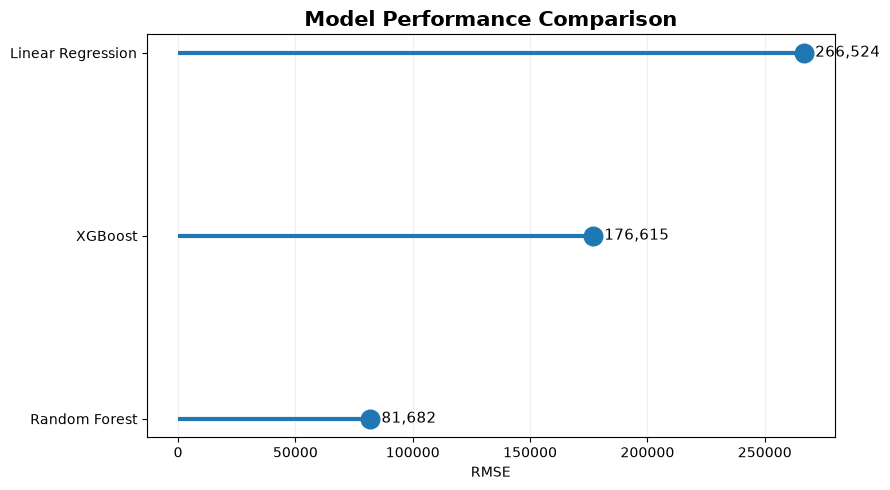

In [ ]:
import matplotlib.pyplot as plt


results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [266523.871, 81682.120, 176615.359]
})


results = results.sort_values('RMSE')

plt.figure(figsize=(9, 5))
plt.hlines( y=results['Model'], xmin=0, xmax=results['RMSE'], linewidth=3)
plt.scatter(results['RMSE'],results['Model'],s=180)
for i, value in enumerate(results['RMSE']):

    plt.text( value + 5000, i, f'{value:,.0f}', va='center', fontsize=11)

plt.xlabel('RMSE')
plt.ylabel('')
plt.title('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

## The model comparison shows the RMSE performance of the three regression models.
## Random Forest currently has the lowest validation RMSE among our three experiments

# Feature importance

In [ ]:
feature_names = model_rf.named_steps['preprocessor'].get_feature_names_out()

importances = model_rf.named_steps['regressor'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
5348,remainder__play_count,0.763749
5349,remainder__like_count,0.045473
5354,remainder__whatsapp_share_count,0.020659
5351,remainder__share_count,0.017155
145,cat__music_author_AFVofficial,0.016305
5346,remainder__total_favorited,0.015316
5344,remainder__follower_count,0.014397
5325,remainder__author_id,0.007940
5359,remainder__download_rate,0.007503
5343,remainder__fear,0.007306


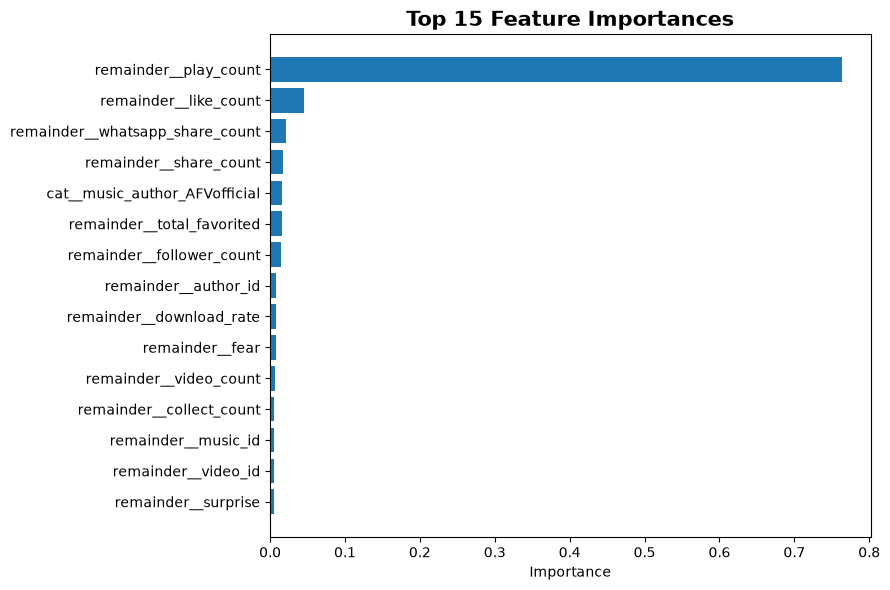

In [ ]:
top_features = feature_importance.head(15).sort_values('Importance')

plt.figure(figsize=(9, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('')
plt.title('Top 15 Feature Importances', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

## preparing test_videos

In [33]:
test_videos['create_date']=pd.to_datetime(test_videos['create_date'])

test_creator_features = test_videos.merge(
    creators_daily,
    left_on=['author_id', 'create_date'],
    right_on=['author_id', 'date'],
    how='left'
)

final_test = test_creator_features.merge(
    engagment_agg,
    on=['video_id'],
    how='left'
)


final_test.shape

(3001, 39)

In [34]:
final_test['share_rate'] = final_test['share_count'] / final_test['play_count']
final_test['like_rate'] = final_test['like_count'] / final_test['play_count']
final_test['comment_rate'] = final_test['comment_count'] / final_test['play_count']
final_test['collect_rate'] = final_test['collect_count'] / final_test['play_count']
final_test['download_rate'] = final_test['download_count'] / final_test['play_count']
final_test['whatsapp_share_rate'] = final_test['whatsapp_share_count'] / final_test['play_count']

In [35]:
final_test.isna().sum()[final_test.isna().sum() > 0]

music_selected_from      31
music_author              7
music_owner_id          719
music_id                  1
word_count             1049
emoji_count            1049
question_count         1049
hashtag_count          1049
speaking_rate          1049
anger                    15
joy                      15
surprise                 15
sadness                  15
disgust                  15
fear                     15
enterprise_verified    3001
dtype: int64

In [36]:
final_test = final_test.drop(columns=['enterprise_verified'])
final_test['music_selected_from']=final_test['music_selected_from'].fillna('Unknown')
final_test['music_author']=final_test['music_author'].fillna('Unknown')
final_test['music_owner_id']=final_test['music_owner_id'].fillna(-1)
final_test['music_id']=final_test['music_id'].fillna(-1)


numeric_missing = [
    'word_count',
    'emoji_count',
    'question_count',
    'hashtag_count',
    'speaking_rate',
    'anger',
    'joy',
    'surprise',
    'sadness',
    'disgust',
    'fear'
]

for col in numeric_missing:
    final_test[col] = final_test[col].fillna(final_train[col].median())


In [37]:
final_test['create_time'] = pd.to_datetime(
    final_test['create_time']
).dt.hour

final_test = final_test.drop(columns=['date', 'create_date'])

In [38]:
final_test.isna().sum()[final_test.isna().sum() > 0]

Series([], dtype: int64)

In [39]:
feature_cols = X_train.columns.tolist()

X_test = final_test[feature_cols]

print(X_test.shape)
print(X_test.columns.tolist() == X_train.columns.tolist())

(3001, 42)
True


In [40]:
test_predictions = model_rf.predict(X_test)

print(test_predictions.shape)
print(test_predictions[:5])

(3001,)
[ 269.1586028   389.94059983 2697.3405189   309.44880688  263.12389033]


In [42]:
submission = pd.DataFrame({
    'video_id': test_videos['video_id'],
    'target_day30_views': test_predictions
})

submission.to_csv('submission.csv', index=False)

print(submission.shape)
print(submission.head())

import os

print(os.path.abspath('submission.csv'))

(3001, 2)
              video_id  target_day30_views
0  7400582591771938090          269.158603
1  7403167206978374958          389.940600
2  7435124823820356906         2697.340519
3  7409800970143714606          309.448807
4  7410935177553333550          263.123890
c:\Users\marya\Downloads\com\submission.csv
